# Mutual Fund Analytics
## Exploratory Data Analysis (EDA)

**Project:** Capstone Project I - Mutual Fund Analytics

**Objective:**
Perform exploratory data analysis on mutual fund datasets to identify trends, investor behaviour, fund performance, and key business insights.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("="*60)
    print(name)
    print("Shape :", df.shape)

Fund Master
Shape : (40, 15)
NAV History
Shape : (46000, 3)
AUM
Shape : (90, 5)
SIP
Shape : (48, 6)
Category
Shape : (144, 3)
Folio
Shape : (21, 6)
Performance
Shape : (40, 19)
Transactions
Shape : (32778, 13)
Portfolio
Shape : (322, 8)
Benchmark
Shape : (8050, 3)


In [4]:
for name, df in datasets.items():
    print("="*60)
    print(name)
    print(df.columns.tolist())
    print()

Fund Master
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV History
['amfi_code', 'date', 'nav']

AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Category
['month', 'category', 'net_inflow_crore']

Folio
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

Performance
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

Transaction

In [5]:
nav_history.head()
nav_history.info()
nav_history.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.5 MB


,amfi_code,date,nav
count,46000.000000,46000,46000.000000
unique,NaN,1150,NaN
top,NaN,2022-01-03,NaN
freq,NaN,40,NaN
mean,120247.000000,NaN,269.570265
std,14352.317221,NaN,577.187060
min,100016.000000,NaN,26.136600
25%,118632.750000,NaN,69.170425
50%,119551.500000,NaN,122.732150
75%,120842.250000,NaN,260.338675


In [6]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [7]:
print("Unique AMFI Codes :", nav_history["amfi_code"].nunique())

Unique AMFI Codes : 40


In [8]:
fund_master.head()
fund_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 9.9 KB


In [9]:
nav_df = nav_history.merge(fund_master, on="amfi_code", how="left")

print(nav_df.shape)
nav_df.head()

(46000, 17)


,amfi_code,date,nav,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,2022-01-03,54.3856,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119551,2022-01-04,54.3474,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119551,2022-01-05,54.6869,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
3,119551,2022-01-06,55.4550,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
4,119551,2022-01-07,55.3692,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01


In [10]:
nav_df.info()
print(nav_df["scheme_name"].isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   amfi_code           46000 non-null  int64         
 1   date                46000 non-null  datetime64[us]
 2   nav                 46000 non-null  float64       
 3   fund_house          46000 non-null  str           
 4   scheme_name         46000 non-null  str           
 5   category            46000 non-null  str           
 6   sub_category        46000 non-null  str           
 7   plan                46000 non-null  str           
 8   launch_date         46000 non-null  str           
 9   benchmark           46000 non-null  str           
 10  expense_ratio_pct   46000 non-null  float64       
 11  exit_load_pct       46000 non-null  float64       
 12  min_sip_amount      46000 non-null  int64         
 13  min_lumpsum_amount  46000 non-null  int64         
 14  f

In [11]:
daily_nav = (nav_df.groupby("date", as_index=False)["nav"].mean())

daily_nav.head()

,date,nav
0,2022-01-03,207.213793
1,2022-01-04,206.890585
2,2022-01-05,207.226548
3,2022-01-06,207.190405
4,2022-01-07,207.081100


In [12]:
fig = px.line(
    daily_nav,
    x="date",
    y="nav",
    title="Average Daily NAV Trend (2022–2026)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="lightgreen",
    opacity=0.20,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="lightcoral",
    opacity=0.15,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    width=1200,
    height=600,
    font=dict(size=15),
    xaxis_title="Date",
    yaxis_title="Average NAV"
)

fig.show()

### 📌 Observation

Average NAV showed a consistent upward trend from 2022 to 2026.
A stronger growth phase is visible during 2023, while 2024 experienced comparatively slower growth before recovering again.

### 💼 Business Insight

The mutual fund industry demonstrated long-term growth despite short-term market fluctuations, indicating resilient investor confidence and sustained wealth creation.

# Chart 2 : AUM Growth by Fund House

In [13]:
aum.head()
aum.info()
aum.columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 6.0 KB


['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

In [14]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [15]:
fig = px.bar(
    aum,
    x="fund_house",
    y="aum_lakh_crore",
    color=aum["year"].astype(str),
    barmode="group",
    title="AUM Growth by Fund House (2022–2025)"
)

fig.add_annotation(
    x="SBI Mutual Fund",
    y=13.5,
    text="SBI ₹12.5 L Cr",
    showarrow=True,
    arrowhead=2,
    ax=-40,
    ay=-50
)

fig.update_xaxes(tickangle=-20)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    width=1200,
    height=600,
    legend_title="Year",
    xaxis_title="Fund House",
    yaxis_title="AUM (Lakh Crore ₹)"
)

fig.show()

###  Observation

SBI Mutual Fund maintained the highest Assets Under Management (AUM), reaching ₹12.5 lakh crore by 2025. Most major fund houses recorded steady year-over-year growth in AUM, indicating sustained expansion across the mutual fund industry.

###  Business Insight

The consistent increase in AUM reflects rising investor confidence and long-term wealth creation through mutual funds. SBI Mutual Fund continued to lead the market, demonstrating strong brand trust and market leadership.

In [16]:
aum.sort_values("date", ascending=False).head(15)
aum[aum["fund_house"].str.contains("SBI", case=False)]

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
10,2022-09-30,SBI Mutual Fund,6.30,630000,186,2022
20,2023-03-31,SBI Mutual Fund,7.17,717000,186,2023
30,2023-09-30,SBI Mutual Fund,8.45,845000,186,2023
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186,2024
50,2024-09-30,SBI Mutual Fund,10.80,1080000,186,2024
60,2024-12-31,SBI Mutual Fund,11.14,1114000,186,2024
70,2025-03-31,SBI Mutual Fund,12.50,1250000,186,2025
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186,2025


# Chart 3 : Monthly SIP Inflow Trend (2022–2025)

In [17]:
sip.head()
sip.info()
sip.columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.7 KB


['month',
 'sip_inflow_crore',
 'active_sip_accounts_crore',
 'new_sip_accounts_lakh',
 'sip_aum_lakh_crore',
 'yoy_growth_pct']

In [18]:
sip["month"] = pd.to_datetime(sip["month"])

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [19]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022–2025)",
    markers=True
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="All-Time High ₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    ax=-70,
    ay=-50
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    width=1200,
    height=600,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.show()

In [20]:
sip.sort_values("sip_inflow_crore", ascending=False).head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
47,2025-12-01,31002,9.35,9.80,15.90,17.17
46,2025-11-01,30200,9.20,9.10,15.72,19.27
45,2025-10-01,29529,9.10,9.45,15.55,16.61
44,2025-09-01,29361,9.00,10.50,15.38,19.80
42,2025-07-01,28464,8.75,10.20,14.05,22.00


###  Observation

Monthly SIP inflows increased consistently from around ₹11,500 crore in early 2022 to an all-time high of ₹31,002 crore in December 2025. The trend indicates sustained growth in systematic investment participation.

###  Business Insight

The continuous rise in SIP inflows reflects increasing retail investor confidence and long-term investment discipline. Record SIP contributions suggest strong market participation and growing awareness of wealth creation through mutual funds.

#  Chart 4 : Category-wise Inflow Distribution

In [21]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

In [22]:
category.head()
category.info()
category.columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 5.8 KB


['month', 'category', 'net_inflow_crore']

In [23]:
print(category.columns)
category.head()

Index(['month', 'category', 'net_inflow_crore'], dtype='str')


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [24]:
category["month"] = pd.to_datetime(category["month"])
category["month"] = category["month"].dt.strftime("%b-%Y")

In [25]:
fig = px.bar(
    category,
    x="month",
    y="net_inflow_crore",
    color="category",
    barmode="group",
    title="Category-wise Mutual Fund Net Inflow (2024)"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    width=1200,
    height=600,
    xaxis_title="Month",
    yaxis_title="Net Inflow (₹ Crore)",
    legend_title="Category"
)

fig.show()

In [26]:
category.sort_values(
    "net_inflow_crore",
    ascending=False
).head(10)

,month,category,net_inflow_crore
56,Aug-2024,Liquid,41952.0
20,May-2024,Liquid,41872.0
92,Nov-2024,Liquid,40506.0
32,Jun-2024,Liquid,40486.0
80,Oct-2024,Liquid,39091.0
140,Mar-2025,Liquid,38681.0
8,Apr-2024,Liquid,37537.0
68,Sep-2024,Liquid,35308.0
104,Dec-2024,Liquid,34933.0
44,Jul-2024,Liquid,34643.0


##  Observation

Net inflows varied across mutual fund categories during 2024. Flexi Cap, Large & Mid Cap, and Mid Cap funds consistently attracted higher inflows than most other categories, indicating stronger investor preference for diversified and growth-oriented investment options.

##  Business Insight

Investors showed greater interest in diversified equity categories, particularly Flexi Cap and Large & Mid Cap funds. This trend suggests a preference for balanced risk exposure and long-term wealth creation, highlighting these categories as key drivers of mutual fund industry growth.

In [27]:
category.sort_values(
    "net_inflow_crore",
    ascending=False
).head(10)

,month,category,net_inflow_crore
56,Aug-2024,Liquid,41952.0
20,May-2024,Liquid,41872.0
92,Nov-2024,Liquid,40506.0
32,Jun-2024,Liquid,40486.0
80,Oct-2024,Liquid,39091.0
140,Mar-2025,Liquid,38681.0
8,Apr-2024,Liquid,37537.0
68,Sep-2024,Liquid,35308.0
104,Dec-2024,Liquid,34933.0
44,Jul-2024,Liquid,34643.0


#  Chart 5 : Industry Folio Growth Trend

In [28]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

In [29]:
folio.head()
folio.info()
folio.columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     str    
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.3 KB


['month',
 'total_folios_crore',
 'equity_folios_crore',
 'debt_folios_crore',
 'hybrid_folios_crore',
 'others_folios_crore']

In [30]:
folio["month"] = pd.to_datetime(folio["month"])
folio["month"] = folio["month"].dt.strftime("%b-%Y")

In [31]:
fig = px.line(
    folio,
    x="month",
    y=[
        "equity_folios_crore",
        "debt_folios_crore",
        "hybrid_folios_crore",
        "others_folios_crore"
    ],
    markers=True,
    title="Industry Folio Growth by Category"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    width=1200,
    height=600,
    xaxis_title="Month",
    yaxis_title="Folios (Crore)",
    legend_title="Category"
)

fig.show()

##  Observation

Equity folios showed the strongest and most consistent growth throughout the period, while debt and hybrid folios increased at a comparatively moderate pace. Other folio categories remained relatively stable with smaller contributions.

##  Business Insight

The steady rise in equity folios indicates increasing investor participation in equity-oriented mutual funds, reflecting higher confidence in long-term wealth creation. Debt and hybrid products continue to serve investors seeking diversification and lower risk.

In [32]:
folio.sort_values(
    "total_folios_crore",
    ascending=False
).head(10)

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
20,Dec-2025,26.12,18.28,3.66,1.57,2.61
19,Oct-2025,25.60,17.92,3.58,1.54,2.56
18,Sep-2025,25.19,17.63,3.53,1.51,2.52
17,Aug-2025,24.89,17.42,3.48,1.49,2.49
16,Jul-2025,24.57,17.20,3.44,1.47,2.46
15,Apr-2025,23.89,16.72,3.34,1.43,2.39
14,Mar-2025,23.45,16.42,3.28,1.41,2.35
13,Jan-2025,23.10,16.17,3.23,1.39,2.31
12,Dec-2024,22.89,16.02,3.20,1.37,2.29
11,Oct-2024,21.62,15.13,3.03,1.30,2.16


#  Chart 6 : Investor Transaction Type Distribution

In [33]:
transactions.head()
transactions.info()
transactions.columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 5.4 MB


['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

In [34]:
txn = (
    transactions
    .groupby("transaction_type")
    .size()
    .reset_index(name="count")
)

txn

,transaction_type,count
0,Lumpsum,8095
1,Redemption,4967
2,SIP,19716


In [35]:
fig = px.pie(
    txn,
    names="transaction_type",
    values="count",
    hole=0.45,
    title="Investor Transaction Type Distribution"
)

fig.update_traces(textposition="inside", textinfo="percent+label")

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    width=900,
    height=600
)

fig.show()

In [36]:
txn.sort_values("count", ascending=False)

,transaction_type,count
2,SIP,19716
0,Lumpsum,8095
1,Redemption,4967


##  Observation

SIP transactions accounted for the largest share of investor activity, followed by Lumpsum investments, while Redemptions formed the smallest proportion. This reflects a strong preference for disciplined long-term investing over frequent withdrawals.

##  Business Insight

The dominance of SIP transactions indicates growing investor confidence in systematic wealth creation. Lower redemption activity suggests that investors are maintaining long-term investment strategies, which contributes to stable fund inflows for asset management companies.

#  Chart 7 : State-wise Investor Distribution

In [37]:
transactions["state"].value_counts().head()
transactions["state"].nunique()
transactions["state"].unique()

<ArrowStringArray>
[     'Telangana',         'Punjab',        'Haryana',    'Maharashtra',
          'Delhi', 'Madhya Pradesh',        'Gujarat',      'Rajasthan',
  'Uttar Pradesh',      'Karnataka',    'West Bengal',     'Tamil Nadu']
Length: 12, dtype: str

In [38]:
state_dist = (
    transactions
    .groupby("state")
    .size()
    .reset_index(name="investors")
    .sort_values("investors", ascending=False)
)

state_dist.head(10)

,state,investors
6,Punjab,2965
4,Madhya Pradesh,2931
8,Tamil Nadu,2806
1,Gujarat,2780
11,West Bengal,2748
2,Haryana,2736
9,Telangana,2718
10,Uttar Pradesh,2695
0,Delhi,2677
3,Karnataka,2621


In [39]:
fig = px.bar(
    state_dist,
    x="state",
    y="investors",
    color="investors",
    title="State-wise Investor Distribution"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    width=1200,
    height=600,
    xaxis_title="State",
    yaxis_title="Number of Investors"
)

fig.show()

In [40]:
state_dist.head(10)

,state,investors
6,Punjab,2965
4,Madhya Pradesh,2931
8,Tamil Nadu,2806
1,Gujarat,2780
11,West Bengal,2748
2,Haryana,2736
9,Telangana,2718
10,Uttar Pradesh,2695
0,Delhi,2677
3,Karnataka,2621


##  Observation

Investor participation was concentrated in a few major states, while the remaining states contributed comparatively fewer investors. This indicates regional differences in mutual fund adoption across India.

##  Business Insight

States with higher investor participation represent mature mutual fund markets, whereas states with lower participation provide opportunities for investor awareness campaigns and market expansion.

#  Chart 8 : Payment Mode Distribution

In [41]:
transactions["payment_mode"].value_counts()
transactions["payment_mode"].unique()

<ArrowStringArray>
['UPI', 'Cheque', 'Mandate', 'Net Banking']
Length: 4, dtype: str

In [42]:
payment = (
    transactions
    .groupby("payment_mode")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

payment

,payment_mode,count
2,Net Banking,8250
0,Cheque,8228
3,UPI,8154
1,Mandate,8146


In [43]:
fig = px.bar(
    payment,
    x="payment_mode",
    y="count",
    color="count",
    text="count",
    title="Payment Mode Distribution"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    width=1000,
    height=600,
    xaxis_title="Payment Mode",
    yaxis_title="Number of Transactions"
)

fig.show()

In [44]:
payment

,payment_mode,count
2,Net Banking,8250
0,Cheque,8228
3,UPI,8154
1,Mandate,8146


##  Observation

UPI and Net Banking accounted for the majority of investment transactions, while Cheque and Mandate-based transactions were comparatively lower, indicating a strong preference for digital payment methods.

##  Business Insight

The increasing adoption of digital payment modes reflects growing investor convenience and digital financial inclusion. Asset management companies should continue strengthening digital investment platforms to improve customer experience and transaction efficiency.

#  Chart 9 : Age Group-wise Investor Distribution

In [45]:
transactions["age_group"].value_counts()
transactions["age_group"].unique()

<ArrowStringArray>
['56+', '18-25', '36-45', '26-35', '46-55']
Length: 5, dtype: str

In [46]:
age = (
    transactions
    .groupby("age_group")
    .size()
    .reset_index(name="investors")
)

age

,age_group,investors
0,18-25,4916
1,26-35,13463
2,36-45,8146
3,46-55,3779
4,56+,2474


In [47]:
fig = px.bar(
    age,
    x="age_group",
    y="investors",
    color="investors",
    text="investors",
    title="Age Group-wise Investor Distribution"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    width=1000,
    height=600,
    xaxis_title="Age Group",
    yaxis_title="Number of Investors"
)

fig.show()

In [48]:
age.sort_values("investors", ascending=False)

,age_group,investors
1,26-35,13463
2,36-45,8146
0,18-25,4916
3,46-55,3779
4,56+,2474


##  Observation

The 26–35 and 36–45 age groups contributed the highest number of investors, while participation was comparatively lower among younger (18–25) and older (56+) age groups.

##  Business Insight

The dominance of middle-aged investors reflects higher earning capacity and greater financial planning awareness. Asset management companies can target younger investors through financial literacy initiatives and digital investment campaigns to expand the investor base.

#  Chart 10 : KYC Status Distribution

In [49]:
transactions["kyc_status"].value_counts()
transactions["kyc_status"].unique()

<ArrowStringArray>
['Verified', 'Pending']
Length: 2, dtype: str

In [50]:
kyc = (
    transactions
    .groupby("kyc_status")
    .size()
    .reset_index(name="count")
)

kyc

,kyc_status,count
0,Pending,2632
1,Verified,30146


In [51]:
fig = px.pie(
    kyc,
    names="kyc_status",
    values="count",
    hole=0.45,
    title="KYC Status Distribution"
)

fig.update_traces(textposition="inside", textinfo="percent+label")

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    width=900,
    height=600
)

fig.show()

In [52]:
kyc.sort_values("count", ascending=False)

,kyc_status,count
1,Verified,30146
0,Pending,2632


##  Observation

Most investors completed KYC verification, while only a small proportion remained pending. This indicates a high level of regulatory compliance across the investor base.

##  Business Insight

A high percentage of KYC-verified investors enables smoother onboarding, regulatory compliance, and faster transaction processing. Reducing pending KYC cases can further improve customer experience and operational efficiency.

# NAV Return Correlation Matrix

In [53]:
print(nav_history.columns.tolist())

['amfi_code', 'date', 'nav']


In [54]:
print(nav_history["amfi_code"].nunique())
print(nav_history["amfi_code"].unique()[:10])

40
[119551 119552 119598 119599 119120 100016 125497 100033 125498 100025]


In [55]:
top10 = nav_history["amfi_code"].unique()[:10]

corr_df = nav_history[
    nav_history["amfi_code"].isin(top10)
].copy()

In [56]:
corr_df["daily_return"] = corr_df.groupby("amfi_code")["nav"].pct_change()

In [57]:
pivot = corr_df.pivot_table(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

corr = pivot.corr()

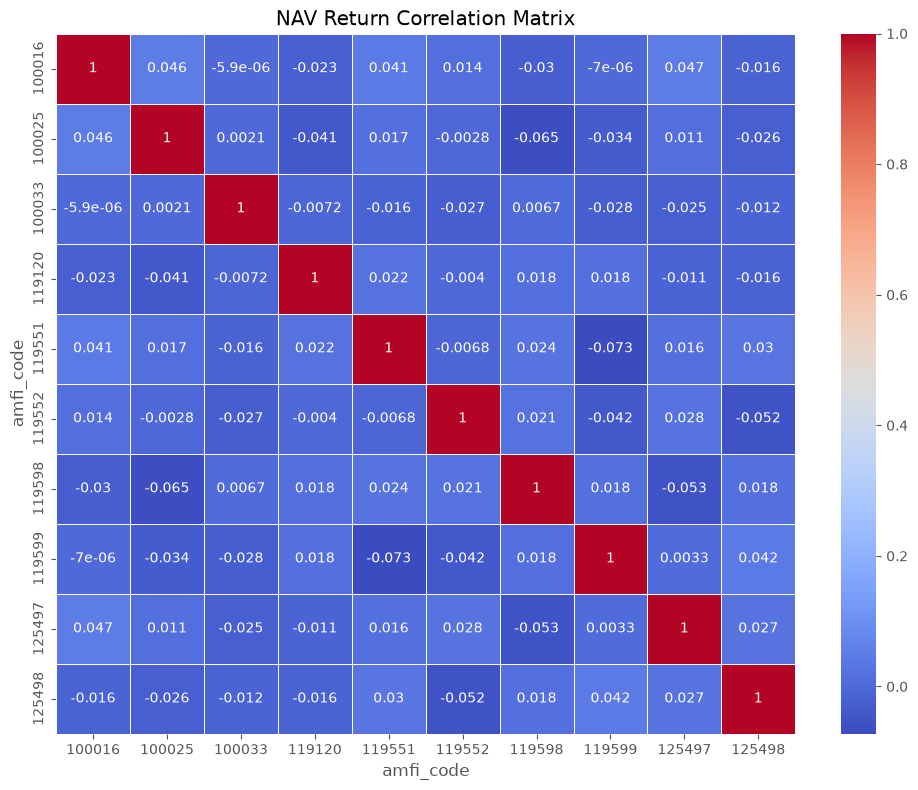

In [58]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("NAV Return Correlation Matrix")
plt.tight_layout()
plt.show()

##  Observation

Most selected mutual funds show a positive correlation in daily NAV returns, indicating that they generally move in the same market direction. However, the correlation strength varies across different funds.

##  Business Insight

Highly correlated funds provide lower diversification benefits. Investors should combine funds with lower correlations to build a more balanced and risk-efficient portfolio.

In [59]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


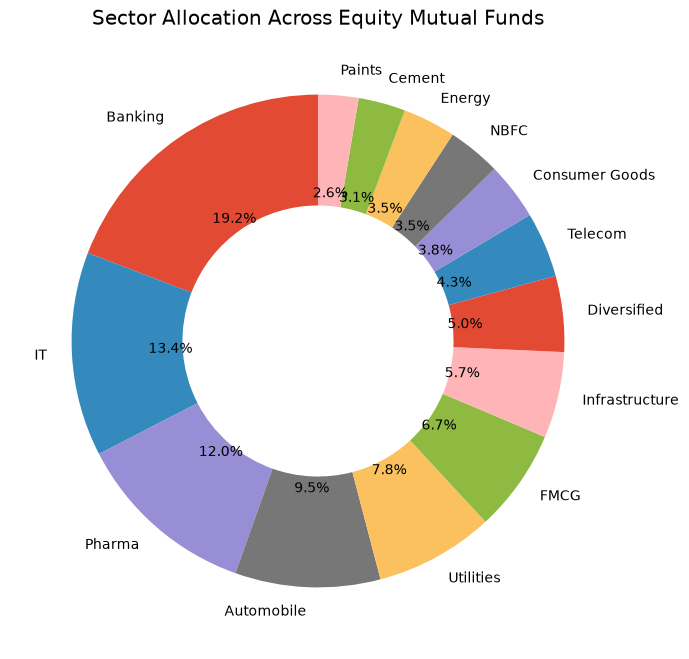

In [60]:
import matplotlib.pyplot as plt

sector_data = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.45}
)

plt.title("Sector Allocation Across Equity Mutual Funds")
plt.show()

##  Observation

Financials, Information Technology, and Banking sectors account for a significant share of mutual fund portfolios, indicating a strong preference for large-cap and stable industries.

##  Business Insight

Sector diversification helps reduce portfolio risk. Investors should avoid excessive exposure to a single sector and maintain balanced allocations across industries.